In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
from go_ml.eval_utils import filter_annot_df
from go_ml.eval_utils import (load_msa_dict, gen_bert_mat, get_bert_entropy, 
                              gen_annot_mat, gen_seq_len_mask, mean_reciprocal_rank, 
                              mean_reciprocal_rank_mat, mean_auc, top_30_score, roc_average)

data_root = '../gen_datasets/datasets'
csa_df = filter_annot_df(pd.read_csv(f'{data_root}/csa_annot.csv', sep='\t'))
llps_df = filter_annot_df(pd.read_csv(f'{data_root}/llps_dataset.csv', sep='\t'))
elms_df = filter_annot_df(pd.read_csv(f'{data_root}/elms_dataset.csv', sep='\t'))

In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from esm.models.esmc import ESMC
device = torch.device('cuda:0')
model = ESMC.from_pretrained("esmc_600m").to(device) # or "cpu"
vi = {i: a for a, i in model.tokenizer.get_vocab().items()}
AA_str = [vi[i] for i in range(4, 24)]
from go_ml.masking import mask_perc, get_logits_esmc

In [5]:
from tqdm.notebook import tqdm
import pickle

ds_labels = ['csa', 'llps', 'elms']
for ds_label, annot_df in zip(ds_labels, [csa_df, llps_df, elms_df]):
    df_logits = {}
    for i, (seq_id, seq) in tqdm(enumerate(zip(annot_df['UniprotID'], annot_df['Sequence'])), 
                                 total=len(annot_df), desc=f'Processing {ds_label}'):
        df_logits[seq_id] = get_logits_esmc(seq, model, batch_size=8, mask_func=mask_perc)
    bert_map = {k: v[:, 4:24] for k, v in df_logits.items()}
    bert_map = {k: v / v.sum() for k, v in bert_map.items()}
    annot_mat = gen_annot_mat(annot_df['AnnotatedIndices'], [len(s) for s in annot_df['Sequence']])
    seq_len_mask = gen_seq_len_mask(annot_df['Sequence'])
    bert_mat = gen_bert_mat(annot_df['UniprotID'], bert_map, max_len=850)
    bert_entropy = get_bert_entropy(bert_mat, seq_len_mask)
    with open(f'eval_files/{ds_label}_esmc.pkl', 'wb') as f:
            pickle.dump({'UniprotID': annot_df['UniprotID'], 'bert_mat': bert_mat, 
                        'seq_len_mask': seq_len_mask, 'bert_entropy': bert_entropy}, f)
    print(f'DS label: {ds_label}')

Processing csa:   0%|          | 0/784 [00:00<?, ?it/s]

MSA Directory: csa


Processing llps:   0%|          | 0/91 [00:00<?, ?it/s]

MSA Directory: llps


Processing elms:   0%|          | 0/230 [00:00<?, ?it/s]

MSA Directory: elms


In [ ]:
from go_ml.eval_utils import mean_reciprocal_rank, mean_reciprocal_rank_mat, mean_auc, top_30_score
mrr = mean_reciprocal_rank_mat(3-bert_entropy, seq_len_mask, annot_mat)
auc, fpr_l, tpr_l = mean_auc(3 - bert_entropy, seq_len_mask, annot_mat, return_roc=True)
top_30 = top_30_score(3 - bert_entropy, seq_len_mask, annot_mat)
print(mrr, auc, top_30)

Text(0.5, 1.0, 'Mean ROC Curve')

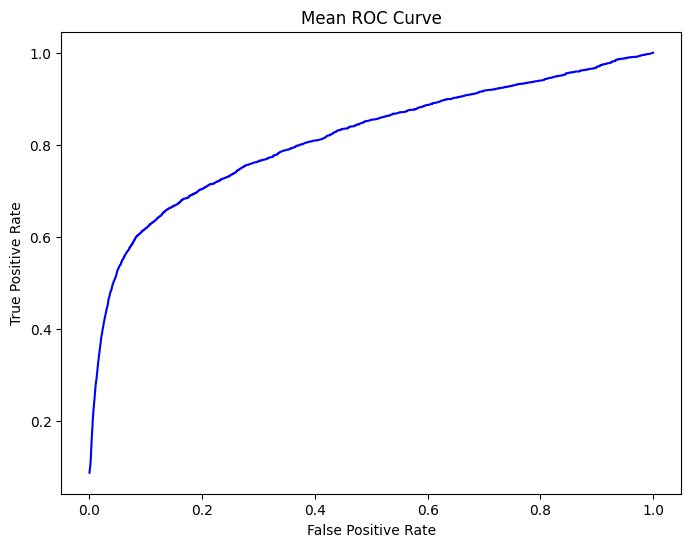

In [21]:
from go_ml.eval_utils import roc_average
mean_fpr, mean_tpr = roc_average(fpr_l, tpr_l)
plt.figure(figsize=(8, 6))
plt.plot(mean_fpr, mean_tpr, color='blue', label='Mean ROC')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Mean ROC Curve')

In [17]:
len(fpr_l[0]), len(fpr_l[1]), len(fpr_l[2]), len(fpr_l[3]), len(fpr_l[4]), len(fpr_l[5])

(367, 310, 403, 270, 707, 513)

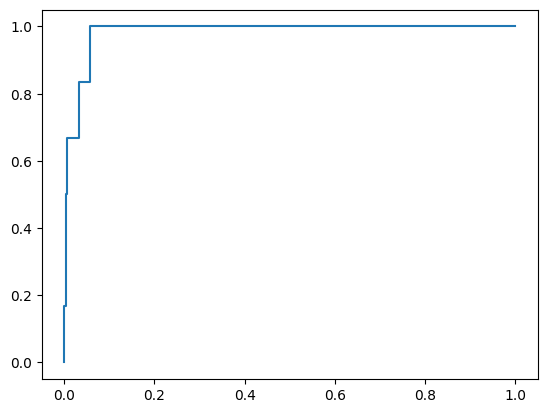

In [19]:
plt.plot(fpr_l[0], tpr_l[0])